# Synthetic vp/vs Deterministic Linear Inference



This notebook is a synthetic DLI example that sits between `dli.ipynb` and `realistic_dli.ipynb`. It stays lightweight by using `NormalModesProvider` only, but it is more structured than `dli.ipynb` because the model space is a direct sum

$$

\mathcal{M} = \mathcal{M}_{vp} \oplus \mathcal{M}_{vs},

$$

with separate synthetic forward-kernel families for the `vp` and `vs` blocks.



We solve a deterministic linear inference problem for two local property targets on the `vp` block. The `vs` block is present in the forward map, so the notebook exercises block operators and direct-sum model structure without introducing the heavier catalog and ellipsoid machinery of `realistic_dli.ipynb`.



The admissible property set is

$$

\mathcal{U} = \mathcal{T}\left(\mathcal{B} \cap G^{-1}(\tilde{d} - \mathcal{V})\right),

$$

where both the model prior set $\mathcal{B}$ and the data-confidence set $\mathcal{V}$ are simple norm balls represented by `BallSupportFunction`.


In [22]:
from intervalinf import IntervalDomain, Lebesgue, Function
from intervalinf import IntegrationConfig, ParallelConfig, LebesgueIntegrationConfig
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider, NullFunctionProvider
from intervalinf.operators import SOLAOperator

from pygeoinf import EuclideanSpace, RowLinearOperator, HilbertSpaceDirectSum
from pygeoinf.convex_analysis import BallSupportFunction
from pygeoinf.backus_gilbert import DualMasterCostFunction
from pygeoinf.convex_optimisation import (
    ProximalBundleMethod,
    solve_support_values,
    best_available_qp_solver,
)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

figures_folder = 'synthetic_vp_vs_dli_figures'
os.makedirs(figures_folder, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


## Numerical Configuration

The spaces are continuous Lebesgue spaces on $[0,1]$, with numerical integration used internally by the operators. We keep the setup modest so the notebook runs quickly while still showing a nontrivial block model.

In [23]:
Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='trapz', n_points=512),
    dual=IntegrationConfig(method='trapz', n_points=512),
    general=IntegrationConfig(method='trapz', n_points=512),
)

sola_integration_cfg = IntegrationConfig(method='trapz', n_points=768)
parallel_cfg = ParallelConfig(enabled=True, n_jobs=4)

function_domain = IntervalDomain(0.0, 1.0)
N = 10
N_d = 100
N_p = 2

M_vp = Lebesgue(
    0, function_domain, basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
M_vs = Lebesgue(
    0, function_domain, basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
M_model = HilbertSpaceDirectSum([M_vp, M_vs])
D = EuclideanSpace(N_d)
P = EuclideanSpace(N_p)

x = function_domain.uniform_mesh(1000)

print(f'Domain         : [{function_domain.a}, {function_domain.b}]')
print(f'Model blocks   : vp + vs')
print(f'Data dim       : {N_d}')
print(f'Property dim   : {N_p}')
print(f'SOLA n_points  : {sola_integration_cfg.n_points}')

Domain         : [0.0, 1.0]
Model blocks   : vp + vs
Data dim       : 100
Property dim   : 2
SOLA n_points  : 768


## Synthetic Forward and Property Operators

Both `vp` and `vs` contribute to the synthetic forward operator through separate `NormalModesProvider` instances. The property operator stays simple: both target properties are bump-function averages on the `vp` block, while the `vs` block contributes zero to the property map.

In [24]:
vp_modes = NormalModesProvider(
    M_vp,
    n_modes_range=(2, 8),
    coeff_range=(-4.0, 4.0),
    gaussian_width_percent_range=(5, 18),
    freq_range=(0.2, 8.0),
    random_state=7,
)
vs_modes = NormalModesProvider(
    M_vs,
    n_modes_range=(3, 9),
    coeff_range=(-3.0, 3.0),
    gaussian_width_percent_range=(6, 20),
    freq_range=(0.3, 10.0),
    random_state=17,
)

G_vp = SOLAOperator(
    M_vp, D, vp_modes,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
G_vs = SOLAOperator(
    M_vs, D, vs_modes,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
G = RowLinearOperator([G_vp, G_vs])

width = 0.18
centers = np.linspace(
    function_domain.a + width / 2,
    function_domain.b - width / 2,
    N_p,
)
target_provider_vp = BumpFunctionProvider(M_vp, centers=centers, default_width=width)
target_provider_vs = NullFunctionProvider(M_vs)

T_vp = SOLAOperator(
    M_vp, P, target_provider_vp,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
T_vs = SOLAOperator(
    M_vs, P, target_provider_vs,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
T = RowLinearOperator([T_vp, T_vs])

print('Block operators created successfully')
print(f'G cache enabled: {G_vp.get_cache_info()["caching_enabled"] and G_vs.get_cache_info()["caching_enabled"]}')
print(f'Property centres: {np.round(centers, 3)}')

Block operators created successfully
G cache enabled: True
Property centres: [0.09 0.91]


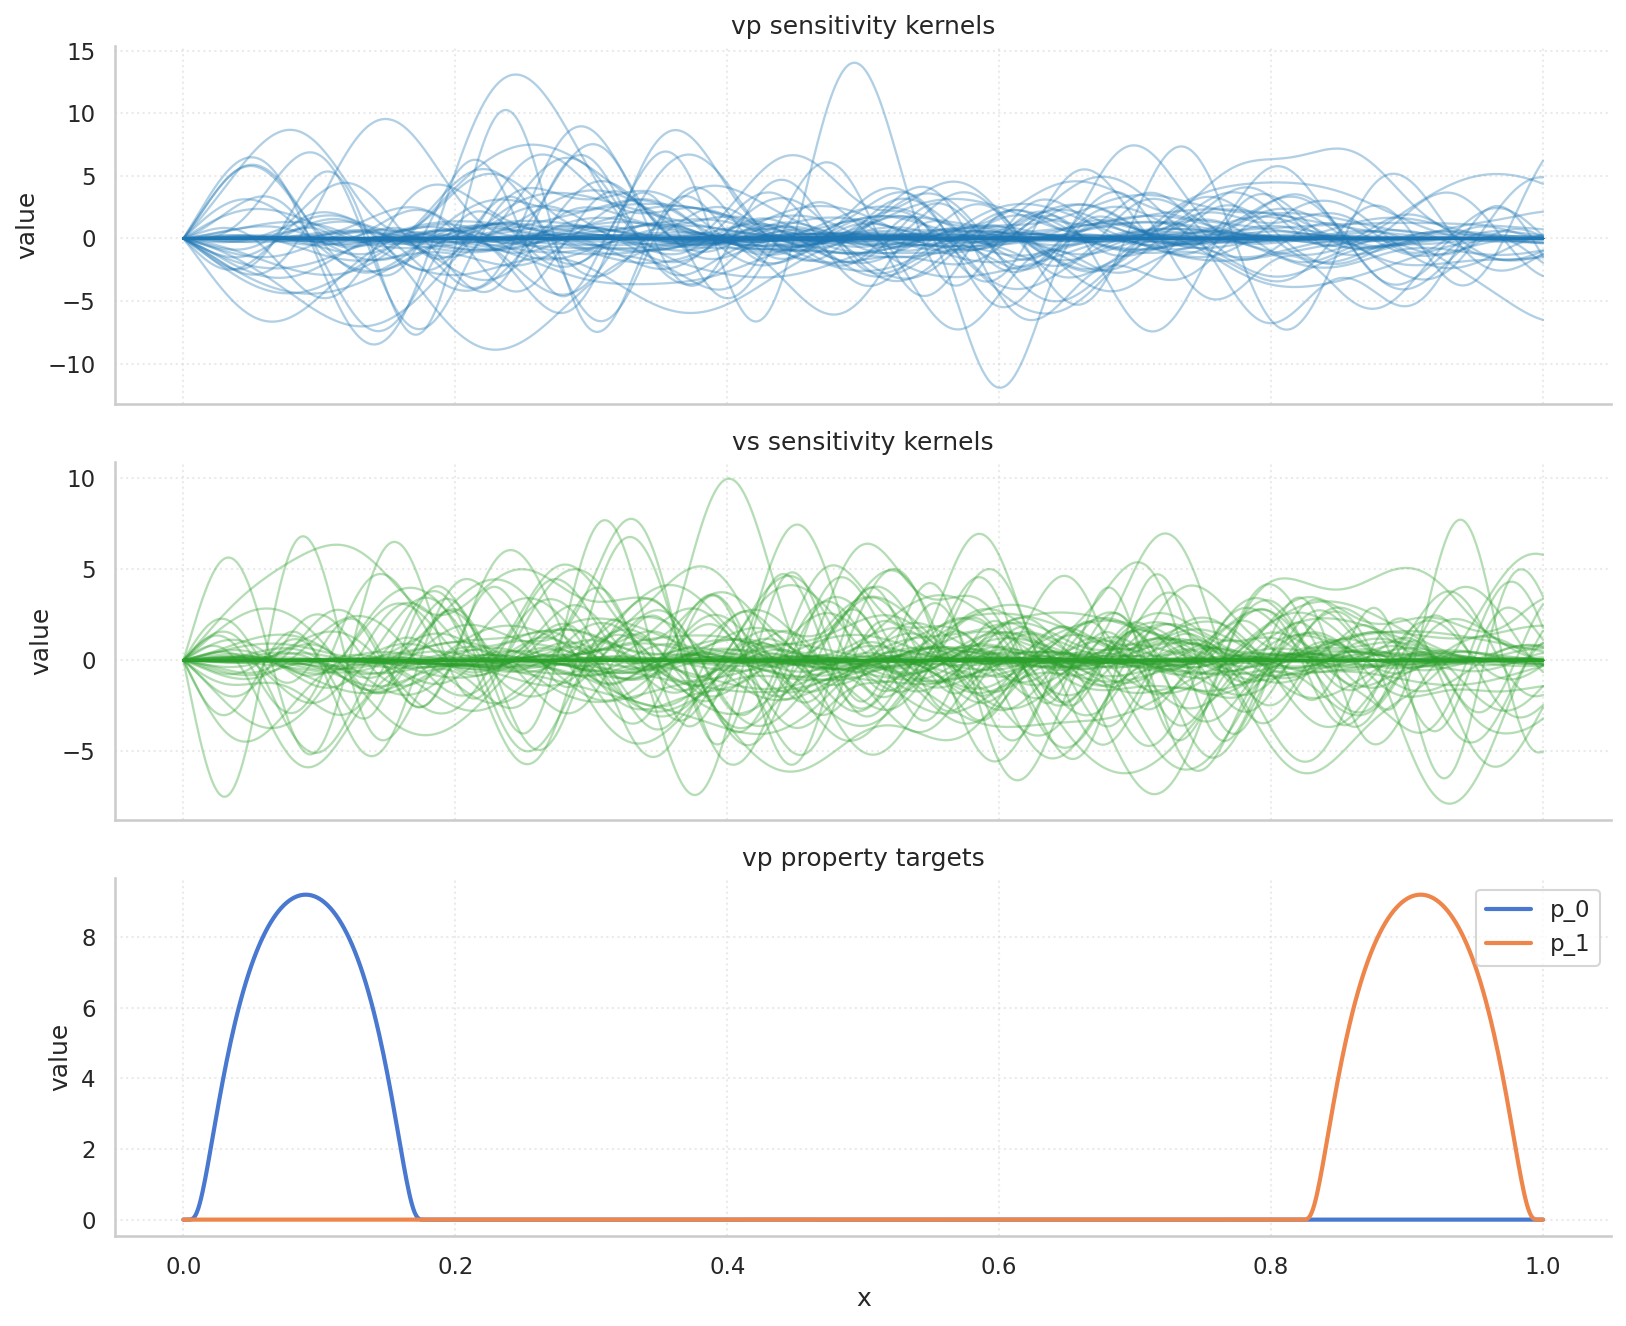

In [25]:
fig, axs = plt.subplots(3, 1, figsize=(11, 9), dpi=150, sharex=True)

for i in range(N_d):
    axs[0].plot(x, G_vp.get_kernel(i).evaluate(x), color='tab:blue', alpha=0.35, linewidth=1.1)
axs[0].set_title(r'vp sensitivity kernels')
axs[0].set_ylabel('value')
axs[0].grid(True, linestyle=':', alpha=0.4)

for i in range(N_d):
    axs[1].plot(x, G_vs.get_kernel(i).evaluate(x), color='tab:green', alpha=0.35, linewidth=1.1)
axs[1].set_title(r'vs sensitivity kernels')
axs[1].set_ylabel('value')
axs[1].grid(True, linestyle=':', alpha=0.4)

for i in range(N_p):
    axs[2].plot(x, T_vp.get_kernel(i).evaluate(x), linewidth=2.0, label=f'p_{i}')
axs[2].set_title(r'vp property targets')
axs[2].set_xlabel('x')
axs[2].set_ylabel('value')
axs[2].legend()
axs[2].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'synthetic_vp_vs_kernels.png'), dpi=200, bbox_inches='tight')
plt.show()

## True Model and Synthetic Data

The true model uses separate seeded cosine-series functions for `vp` and `vs`. This keeps the model continuous and reproducible without introducing a finite basis in model space.

True properties: [ 0.60633 -0.76471]
Noise level    : 0.37313
||d_bar||      : 12.22695
||noise||      : 3.39382


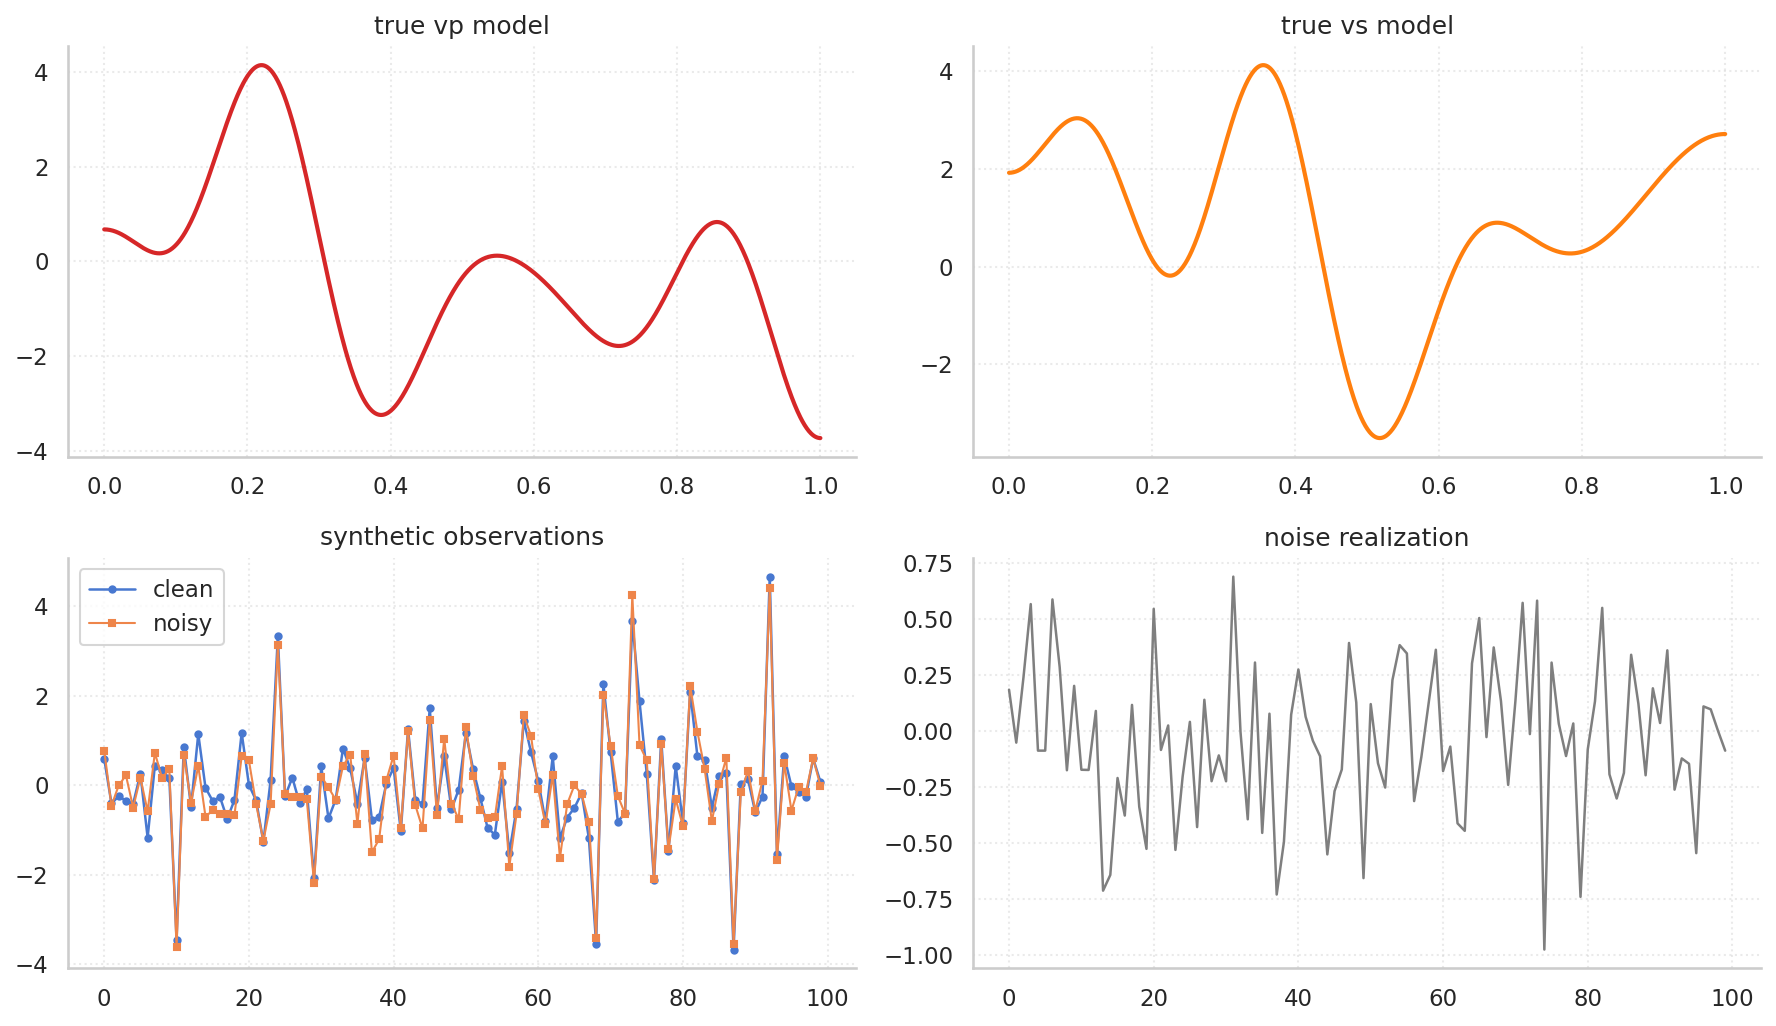

In [26]:
def cosine_series_function(space, coeffs):
    coeffs = np.asarray(coeffs, dtype=float)
    a = space.function_domain.a
    b = space.function_domain.b
    length = b - a

    def evaluate(x):
        x = np.asarray(x, dtype=float)
        xi = (x - a) / length
        values = np.zeros_like(xi, dtype=float)
        if coeffs.size > 0:
            values += coeffs[0] / np.sqrt(length)
        for k, ck in enumerate(coeffs[1:], start=1):
            values += ck * np.sqrt(2.0 / length) * np.cos(np.pi * k * xi)
        return values

    return Function(space, evaluate_callable=evaluate)

vp_coeffs = np.random.RandomState(42).uniform(-1.0, 1.0, N)
vs_coeffs = np.random.RandomState(24).uniform(-1.0, 1.0, N)

m_bar_vp = cosine_series_function(M_vp, vp_coeffs)
m_bar_vs = cosine_series_function(M_vs, vs_coeffs)
m_bar = [m_bar_vp, m_bar_vs]

true_props = T(m_bar)
d_bar = G(m_bar)
noise_level = 0.08 * max(np.max(np.abs(d_bar)), 1e-8)
np.random.seed(42)
noise_vector = np.random.normal(0.0, noise_level, size=N_d)
d_tilde = d_bar + noise_vector

print(f'True properties: {np.round(true_props, 5)}')
print(f'Noise level    : {noise_level:.5f}')
print(f'||d_bar||      : {D.norm(d_bar):.5f}')
print(f'||noise||      : {D.norm(noise_vector):.5f}')

fig, axs = plt.subplots(2, 2, figsize=(12, 7), dpi=150)
axs[0, 0].plot(x, m_bar_vp.evaluate(x), color='tab:red', linewidth=2.0)
axs[0, 0].set_title('true vp model')
axs[0, 0].grid(True, linestyle=':', alpha=0.4)

axs[0, 1].plot(x, m_bar_vs.evaluate(x), color='tab:orange', linewidth=2.0)
axs[0, 1].set_title('true vs model')
axs[0, 1].grid(True, linestyle=':', alpha=0.4)

axs[1, 0].plot(np.arange(N_d), d_bar, marker='o', markersize=3, linewidth=1.2, label='clean')
axs[1, 0].plot(np.arange(N_d), d_tilde, marker='s', markersize=3, linewidth=1.0, label='noisy')
axs[1, 0].set_title('synthetic observations')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle=':', alpha=0.4)

axs[1, 1].plot(np.arange(N_d), noise_vector, color='tab:gray', linewidth=1.2)
axs[1, 1].set_title('noise realization')
axs[1, 1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'synthetic_vp_vs_data.png'), dpi=200, bbox_inches='tight')
plt.show()

## Prior Set, Data-Confidence Set, and DLI Solve

To keep the demo compact, both convex sets are Euclidean balls. The model-prior radius is chosen relative to the norm of the synthetic true model, and the data radius is chosen relative to the realized noise norm. This is intentionally simpler than the ellipsoidal construction in `realistic_dli.ipynb`.

In [27]:
m_0 = M_model.zero
model_radius = 1.35 * M_model.norm(m_bar)
data_radius = 1.25 * D.norm(noise_vector)

model_prior_support = BallSupportFunction(M_model, m_0, model_radius)
data_error_support = BallSupportFunction(D, D.zero, data_radius)

prior_qs = [P.basis_vector(i) for i in range(P.dim)]
prior_upper = np.array([model_prior_support(T.adjoint(q)) for q in prior_qs])
prior_lower = np.array([
    -model_prior_support(M_model.multiply(-1.0, T.adjoint(q)))
    for q in prior_qs
])
prior_mid = 0.5 * (prior_lower + prior_upper)
prior_half = 0.5 * (prior_upper - prior_lower)

cost = DualMasterCostFunction(
    D, P, M_model,
    G, T,
    model_prior_support,
    data_error_support,
    d_tilde,
    P.basis_vector(0),
)

bundle_solver = ProximalBundleMethod(
    cost,
    rho0=1.0,
    rho_factor=2.0,
    tolerance=1e-4,
    max_iterations=300,
    bundle_size=30,
    qp_solver=best_available_qp_solver(),
)

basis_dirs = [P.basis_vector(i) for i in range(P.dim)]
neg_basis_dirs = [P.multiply(-1.0, P.basis_vector(i)) for i in range(P.dim)]
lambda0 = D.zero

solve_t0 = time.perf_counter()
upper_bounds, _, upper_diagnostics = solve_support_values(
    cost, basis_dirs, bundle_solver, lambda0, n_jobs=2
)
lower_neg_values, _, lower_diagnostics = solve_support_values(
    cost, neg_basis_dirs, bundle_solver, lambda0, n_jobs=2
)
solve_elapsed = time.perf_counter() - solve_t0

lower_bounds = -lower_neg_values
mean_values = 0.5 * (lower_bounds + upper_bounds)
property_errors = 0.5 * (upper_bounds - lower_bounds)
reduction = prior_half / np.maximum(property_errors, 1e-12)
within_bounds = int(np.sum((true_props >= lower_bounds) & (true_props <= upper_bounds)))
total_bundle_iterations = sum(d.num_iterations for d in upper_diagnostics + lower_diagnostics)

print(f'Model radius             : {model_radius:.5f}')
print(f'Data radius              : {data_radius:.5f}')
print(f'Solve time               : {solve_elapsed:.2f} s')
print(f'Total bundle iterations  : {total_bundle_iterations}')
print(f'True properties captured : {within_bounds}/{N_p}')

for i in range(N_p):
    inside = lower_bounds[i] <= true_props[i] <= upper_bounds[i]
    print(
        f'p_{i}: prior=[{prior_lower[i]:.4f}, {prior_upper[i]:.4f}]  ' +
        f'post=[{lower_bounds[i]:.4f}, {upper_bounds[i]:.4f}]  ' +
        f'true={true_props[i]:.4f}  inside={inside}'
    )

Model radius             : 3.80329
Data radius              : 4.24228
Solve time               : 15.20 s
Total bundle iterations  : 242
True properties captured : 2/2
p_0: prior=[-10.4167, 10.4167]  post=[-2.6861, 3.0921]  true=0.6063  inside=True
p_1: prior=[-10.4167, 10.4167]  post=[-6.1705, 4.0109]  true=-0.7647  inside=True


## Results

The first panel compares prior and posterior intervals for the two target properties. The second panel shows the half-width reduction achieved by the data.

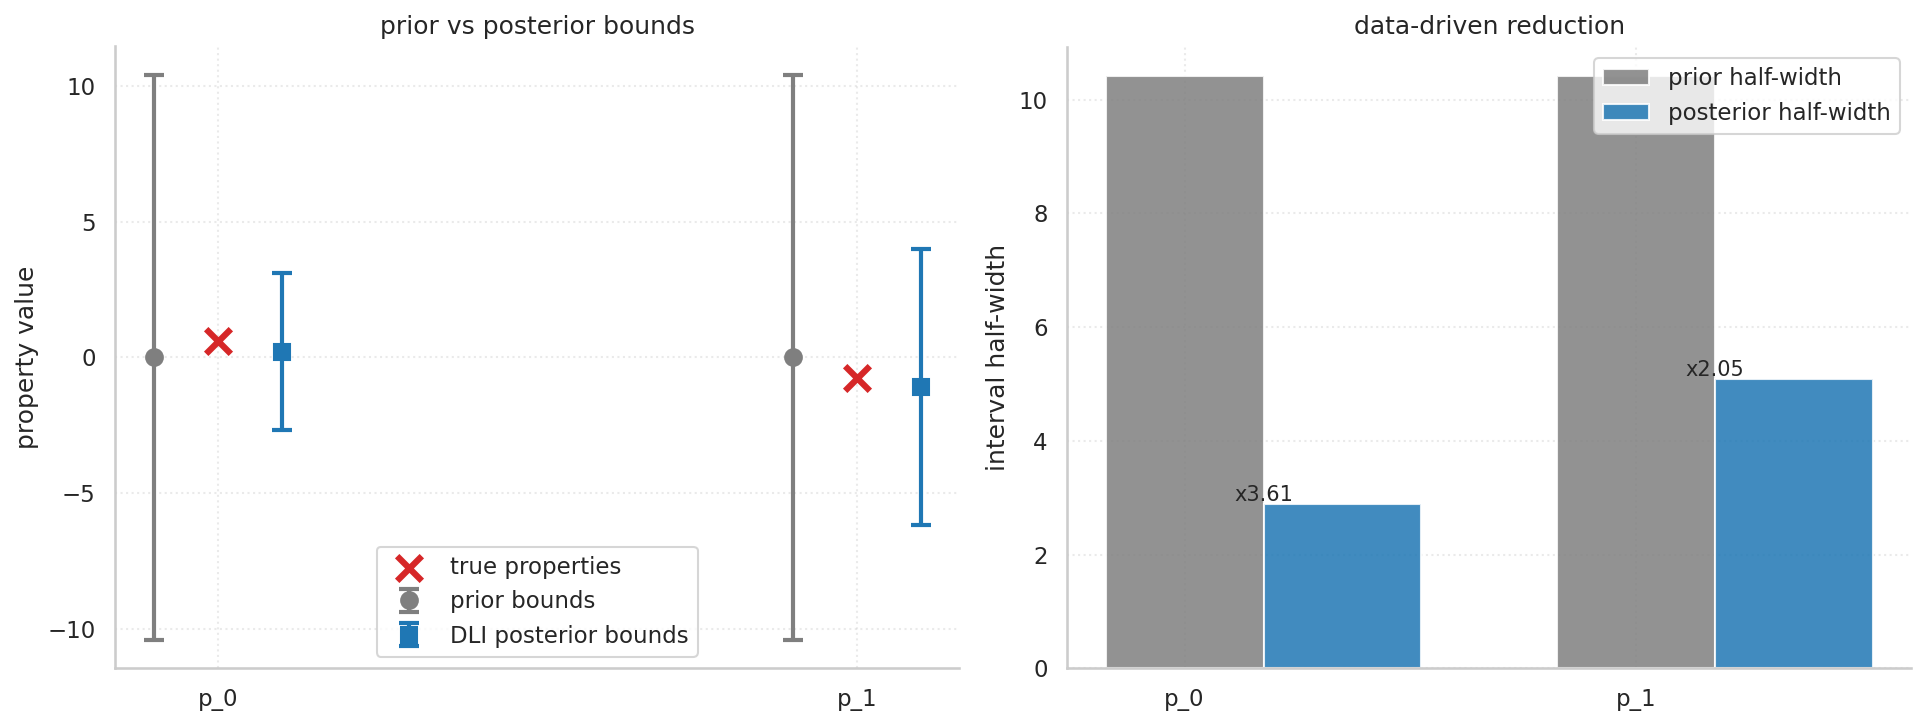

SYNTHETIC VP/VS DLI SUMMARY
Model blocks             : vp + vs
Data dimension           : 100
Property dimension       : 2
Mean prior half-width    : 10.41665
Mean posterior half-width: 3.98986
Mean reduction factor    : 2.83x
Solve time               : 15.20 s


In [28]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

offsets = np.array([-0.1, 0.1])
axs[0].errorbar(
    np.arange(N_p) + offsets[0], prior_mid, yerr=prior_half, fmt='o',
    color='tab:gray', capsize=5, capthick=2, markersize=8, linewidth=2,
    label='prior bounds'
)
axs[0].errorbar(
    np.arange(N_p) + offsets[1], mean_values, yerr=property_errors, fmt='s',
    color='tab:blue', capsize=5, capthick=2, markersize=8, linewidth=2,
    label='DLI posterior bounds'
)
axs[0].scatter(
    np.arange(N_p), true_props, color='tab:red', marker='x',
    s=140, linewidths=3, zorder=10, label='true properties'
)
axs[0].set_xticks(np.arange(N_p))
axs[0].set_xticklabels([f'p_{i}' for i in range(N_p)])
axs[0].set_ylabel('property value')
axs[0].set_title('prior vs posterior bounds')
axs[0].legend()
axs[0].grid(True, linestyle=':', alpha=0.4)

axs[1].bar(np.arange(N_p), prior_half, width=0.35, align='edge', color='tab:gray', alpha=0.85, label='prior half-width')
axs[1].bar(np.arange(N_p) + 0.35, property_errors, width=0.35, align='edge', color='tab:blue', alpha=0.85, label='posterior half-width')
for i in range(N_p):
    axs[1].text(i + 0.35, property_errors[i] + 0.01 * np.max(property_errors), f'x{reduction[i]:.2f}', ha='center', fontsize=10)
axs[1].set_xticks([i + 0.175 for i in range(N_p)])
axs[1].set_xticklabels([f'p_{i}' for i in range(N_p)])
axs[1].set_ylabel('interval half-width')
axs[1].set_title('data-driven reduction')
axs[1].legend()
axs[1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'synthetic_vp_vs_results.png'), dpi=200, bbox_inches='tight')
plt.show()

print('=' * 60)
print('SYNTHETIC VP/VS DLI SUMMARY')
print('=' * 60)
print(f'Model blocks             : vp + vs')
print(f'Data dimension           : {N_d}')
print(f'Property dimension       : {N_p}')
print(f'Mean prior half-width    : {np.mean(prior_half):.5f}')
print(f'Mean posterior half-width: {np.mean(property_errors):.5f}')
print(f'Mean reduction factor    : {np.mean(reduction):.2f}x')
print(f'Solve time               : {solve_elapsed:.2f} s')
print('=' * 60)